In [ ]:
# Import useful functions
# To read DAS data
import nc_array_processing as dnc
# General python libraries
import os
import sys
import numpy as np
import matplotlib.pyplot as plt
import obspy.core as oc
from skimage.util import view_as_blocks, view_as_windows
import torch
import copy
from tqdm import tqdm

# Import DAS-N2N model class (torch version)
from dasn2n import DASN2N
# Build an absolute path from this notebook's parent directory
module_path = os.path.abspath('dasn2n')
# Add to sys.path if not already present
if module_path not in sys.path:
    sys.path.append(module_path)
# Now you can import the desired function or class
from model import ArrayDataset

# Functions to handle the data before feeding them to the trained u-net model
def load_data(fname,start_ch,end_ch):
    '''
    Loading the individual h5 files and cutting a range of channels
    Checked V
    '''
    xsec_febus = dnc.read.febus(fname)
    xsec_febus = dnc.process.decimate(xsec_febus,target_rate=50,exact_rate=True)
    xsec_febus_rmed, median_febus = dnc.process.remove_median(xsec_febus)
    xsec_febus_rmed['data'] = xsec_febus_rmed['data'][start_ch-1:end_ch,:]
    xsec_febus_rmed['header']['channels'] = [start_ch-1,end_ch]
    return xsec_febus_rmed

def pre_proc_data(data,mod):
    '''
    Preprocessing following publication of Lapins 2024
    Take DAS data after basic processing and convert it to data ready for torch training
    Checked V
    '''
    # If swapping axes is necessary (to have time x channels)
    das_numpy_array = np.swapaxes(data, 0, 1)
    # Remove mean and normalize
    offset = np.mean(das_numpy_array, axis=0, keepdims=True) # Mean along time axis (one per channel)
    das_numpy_array = das_numpy_array - offset
    norm_factor = np.std(das_numpy_array, axis=0, keepdims=True) # std along time axis (one per channel)
    das_numpy_array = das_numpy_array / norm_factor
    # Make sure data type is float32 (required for torch model):
    if das_numpy_array.dtype != 'float32':
        das_numpy_array = das_numpy_array.astype('float32')

    # Pad and split data into blocks for model processing (adding what's needed to have round number of blocks)
    das_array_pad = np.pad(das_numpy_array, 
        ((0, mod.INPUT_SHAPE[-2] - (das_numpy_array.shape[-2] % mod.INPUT_SHAPE[-2])), 
        (0, mod.INPUT_SHAPE[-1] - (das_numpy_array.shape[-1] % mod.INPUT_SHAPE[-1]))), 
        mode='reflect')

    # Window data (not overlapping)
    das_array_blocks = view_as_blocks(das_array_pad, tuple(mod.INPUT_SHAPE))

    # Clear some memory
    del(das_numpy_array)
    del(das_array_pad)

    # Reshape to 3D array to feed into model (no_blocks, samples, channels)
    model_in = np.reshape(das_array_blocks, (-1, das_array_blocks.shape[2], das_array_blocks.shape[3]))

    # Clear some memory
    del(das_array_blocks)
    return model_in

In [2]:
# Preparation of data to train the u-net model
pathdata = '/mnt/geofib/1/2025-GRANGEGORMAN_NOISE/2025-10-07_Grangegorman/'
febus_files = []
for x in os.listdir(pathdata):
    if x.endswith(".h5"):
        febus_files.append(x)

febus_files.sort()

# Make list of day and night files (day: noisy data / night: target data)
day_files = []
night_files = []
for x in febus_files:
    if int(x[21:23]) >= 5:
        day_files.append(x)
    else:
        if int(x[21:23]) == 0 and int(x[24:26]) < 30:
            day_files.append(x)
        else:
            night_files.append(x)

In [3]:
# Load the model architecture and weights
mod = torch.load('trained_dasn2n.pt',weights_only=False)
mod = mod.to('cuda') # Uncomment and use 'cuda' or 'mps' (Mac Mx chips) if GPU available

(<Figure size 1000x500 with 2 Axes>, <Axes: xlabel='Time', ylabel='Channels'>)

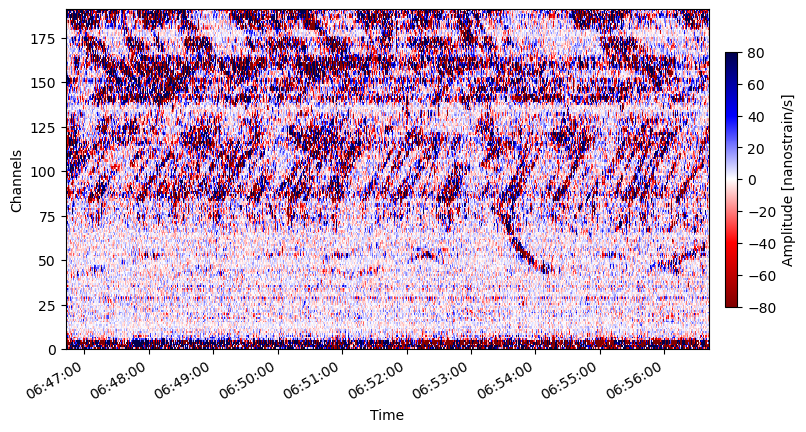

In [4]:
# Load a piece of data to be denoised
xsec_febus_rmed = load_data(pathdata+day_files[102],1,191)
dnc.plot.plot_xsec(xsec=xsec_febus_rmed,fast=True,sat=80)

(<Figure size 1000x500 with 2 Axes>, <Axes: xlabel='Time', ylabel='Channels'>)

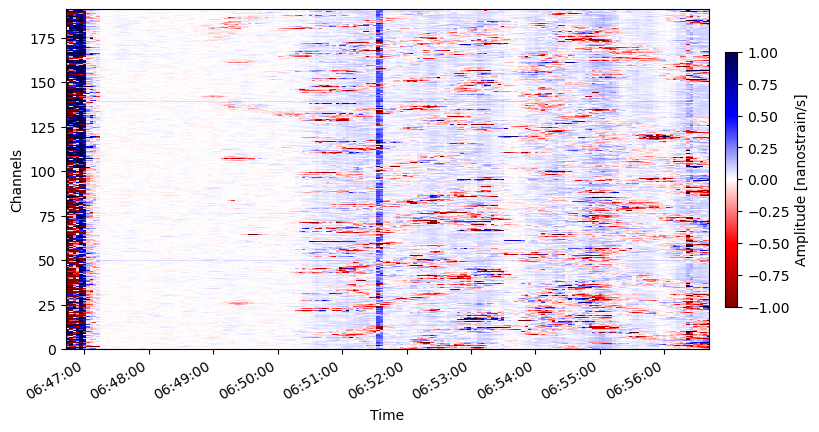

In [5]:
# Pre-format data section and apply model to it
data = xsec_febus_rmed['data']
das_numpy_array = np.swapaxes(data, 0, 1) # Times x channels
denoised_das_data = mod.denoise_numpy(das_numpy_array,batch_size=24,overlap=True,step=0.95
                                      ,normalize=True)

xsec_denoised = dict(xsec_febus_rmed)
xsec_denoised['data'] = denoised_das_data

dnc.plot.plot_xsec(xsec=xsec_denoised,fast=True,sat=1)

(<Figure size 1000x500 with 2 Axes>, <Axes: xlabel='Time', ylabel='Channels'>)

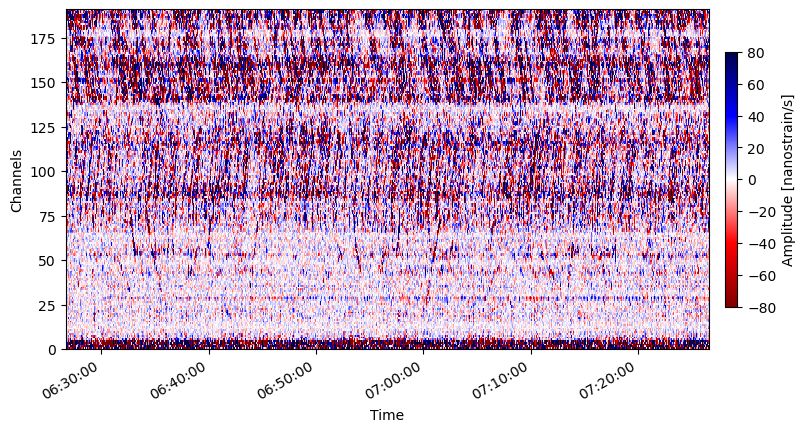

In [ ]:
# Apply the model to a longer time period
nsam = 0.0 # Number of samples
for ii in range(0,6):
    xsec_febus_rmed = load_data(pathdata+day_files[100+ii],1,191)
    if ii==0:
        data_conc = xsec_febus_rmed
    else:
        data_conc['data'] = np.concatenate((data_conc['data'],xsec_febus_rmed['data']),axis=1)
    nsam = nsam + xsec_febus_rmed['header']['time'][1]

data_conc['header']['time'][1] = nsam

dnc.plot.plot_xsec(xsec=data_conc,fast=True,sat=80)

(<Figure size 1000x500 with 2 Axes>, <Axes: xlabel='Time', ylabel='Channels'>)

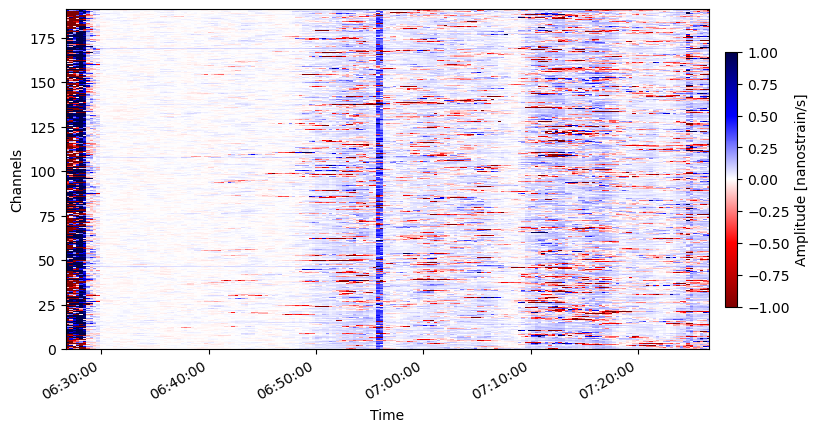

In [ ]:
# Pre-format data section and apply model to it
das_numpy_array = np.swapaxes(data_conc['data'], 0, 1) # Times x channels
denoised_das_data = mod.denoise_numpy(das_numpy_array,batch_size=24,overlap=True,step=0.95
                                      ,normalize=True)

xsec_denoised = dict(data_conc)
xsec_denoised['data'] = denoised_das_data

dnc.plot.plot_xsec(xsec=xsec_denoised,fast=True,sat=1)

In [ ]:
# TRASH
# Might be useful later
from obspy.core import UTCDateTime 
hdr = {'dt': 0.02, 'dx': np.float64(9.6), 'sampling_rate': 50, 'channels': [0, 105], 
       'time': [0, np.float64(599.0)], 'starttime': UTCDateTime(2025, 10, 9, 7, 16, 42, 787242)}
